# Preprocessing and Analysis

In [93]:
# Import necessary packages

import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import matplotlib.dates as mdates

In [94]:
df = pd.read_csv("crawled_data.csv")
df.sample(10)

,Product:,Sale Date:,Category:,Quantity:,Total Price:,Total Profit:,Payment Type:,Customer Details:
1289,Mid Blue Straight Fit Jeans,2025-08-30,Men — Jeans,2,€76.00,€30.40,Credit Card,Cust ID: 15294\nFrom: Limerick\nGender: Female...
1501,Mid Blue Straight Fit Jeans,14-10-2025,Men — Jeans,1,€38.00,€15.20,Debit Card,Customer ID: 6826\nLocation Louth\nGender: F\n...
1294,Lilac/Mint Long Sleeve Shirts,2025-08-30,Children — Girls Clothing,2,€52.00,€26.52,Credit Card,ID: 2369\nFrom: Clare\nGender: Male\nAge Range...
525,Blue Floral Embroidered Mac,"Mar 28, 2025",Children — Girls Clothing,1,35.00,17.85,Credit Card,Age Range: 25-34\nGender: M\nCustomer ID: 1110...
478,Rose Gold Two Tier Drainer,2025-03-19,Homeware — Design,2,€ 55.80,€ 18.60,Credit Card,Customer ID: 18019\nFrom: Tipperary\nGender: M...
883,Mid Blue Slim Fit Ultra Flex Jeans,08 Jun 2025,Men — Jeans,1,€ 48.00,€ 19.20,PayPal,ID: 3000\nLocation Tipperary\nGender: Female\n...
1643,Black Skinny Zip Trousers,08 Nov 2025,Men — Trousers,1,€ 46.00,€ 22.54,Debit Card,ID 1634\nFrom: Cavan\nGender: M\nAge Category:...
190,Dark Wash Straight Fit Jeans,21 Jan 2025,Men — Jeans,1,€ 33.00,€ 13.20,Credit Card,Gender: Prefer not to say\nCity: Kildare\nAge:...
174,Black Skinny Fit Jeans,18 Jan 2025,Men — Jeans,1,€ 46.00,€ 18.40,Debit Card,Cust ID: 18856\nGender: Female\nLocation: Tipp...
1537,Feathers Printed Bed Set,2025-10-20,Homeware — Bed Bath,2,€70.00,€24.50,Credit Card,Gender: Female\nAge: 25—34\nCity: Wicklow\nCus...


In [95]:
# Some utility methods

def visualise_value_proportion(_df: pd.DataFrame, column: str, chart_title: str):
    payment_types = _df[column].value_counts()

    payment_types.plot.pie(
        autopct='%1.1f%%',
        figsize=(6,6),
        ylabel=''
    )

    plt.legend(payment_types.index, loc="upper left", bbox_to_anchor=(0.9, 1))

    plt.title(chart_title)

    plt.show()

# 1. Preprocessing Data

## 1.2. Remove header postfix
Column headers contain a : at the end, which needs to be removed.

In [96]:
print("Before:", df.columns)
df.columns = df.columns.str.rstrip(':')
print("After:", df.columns)

Before: Index(['Product:', 'Sale Date:', 'Category:', 'Quantity:', 'Total Price:',
       'Total Profit:', 'Payment Type:', 'Customer Details:'],
      dtype='str')
After: Index(['Product', 'Sale Date', 'Category', 'Quantity', 'Total Price',
       'Total Profit', 'Payment Type', 'Customer Details'],
      dtype='str')


## 1.3. Sale Dates Column

In [97]:
df['Sale Date'].sample(20)

353     Feb 23, 2025
774       2025-05-21
160       2025-01-15
693       2025-05-03
26       07 Jan 2025
1107      2025-07-26
889       2025-06-09
543       2025-03-31
914       2025-06-15
1658      2025-11-10
93        01-10-2025
873       2025-06-07
1790      2025-12-06
608     Apr 19, 2025
1243     20 Aug 2025
1276     28 Aug 2025
1699      2025-11-18
547       2025-04-06
118       2025-10-04
359       2025-02-25
Name: Sale Date, dtype: str

After reviewing some sample data, the `Sale Date` column was observed to have four formats:
- dd-mm-yyyy (e.g., 17-03-2026)
- yyyy-mm-dd (e.g., 2026-03-17)
- dd Mon yyyy (e.g., 17 Mar 2026)
- Mon dd, yyyy (e.g., Mar 17, 2026)

The following regex can be used to validate these formats and identify any records that do not match them:

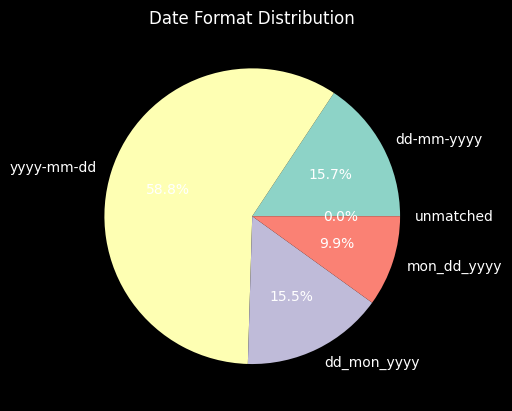

In [98]:
import functools
import operator

patterns = {
    "dd-mm-yyyy": r"^(0[1-9]|[12][0-9]|3[01])-(0[1-9]|1[0-2])-\d{4}$",
    "yyyy-mm-dd": r"^\d{4}-(0[1-9]|1[0-2])-(0[1-9]|[12][0-9]|3[01])$",
    "dd_mon_yyyy": r"^(0?[1-9]|[12][0-9]|3[01])\s(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s\d{4}$",
    "mon_dd_yyyy": r"^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s(0?[1-9]|[12][0-9]|3[01]),\s\d{4}$"
}

# build masks
masks = {
    name: df['Sale Date'].str.match(pattern, na=False)
    for name, pattern in patterns.items()
}

# percentages for known formats
percentages = {
    name: mask.mean() * 100
    for name, mask in masks.items()
}

# unmatched
any_match = functools.reduce(operator.or_, masks.values())
percentages["unmatched"] = (~any_match).mean() * 100

labels = percentages.keys()
sizes = percentages.values()

plt.figure()
plt.pie(sizes, labels=list(labels), autopct='%1.1f%%')
plt.title("Date Format Distribution")
plt.show()

Since all records follow one of the four patterns, we can use the `to_datetime` method to standardize them into a single uniform format

In [99]:
df['Sale Date'] = pd.to_datetime(df['Sale Date'], errors='raise', format='mixed')
df['Sale Date'].sample(10)

1240   2025-08-20
1814   2025-10-12
1098   2025-07-25
1420   2025-09-23
1221   2025-08-17
1726   2025-11-24
338    2025-02-21
994    2025-06-29
816    2025-05-29
991    2025-06-28
Name: Sale Date, dtype: datetime64[us]

## 1.4. Category Column

In [100]:
df["Category"].sample(10)

850     Children — Girls Clothing
799     Children — Girls Clothing
951                  Men — Shirts
957      Children — Boys Clothing
790                   Men — Jeans
817                   Men — Jeans
105     Children — Girls Clothing
1084                 Men — Shirts
286             Homeware — Design
638                Men — Trousers
Name: Category, dtype: str

From above observation, the `Category` column seems follow the pattern X - Y (with X is the main category, Y is the sub category). Build a regex pattern to validate all the records

In [101]:
pattern = r'\s*[—]\s*'

In [102]:
# Mask for rows matching the pattern
mask_match = df['Category'].str.contains(pattern, regex=True, na=False)

print(f"Number of unmatched rows: {(~mask_match).sum()}")

Number of unmatched rows: 0


Since all records follow the pattern, we can split them into 2 different columns

In [103]:
df[['Category_main', 'Category_sub']] = df['Category'].str.split(pattern, n=1, expand=True)
df['Category_main'] = df['Category_main'].str.strip()
df['Category_sub'] = df['Category_sub'].str.strip()

df.drop('Category', axis=1, inplace=True)

df[['Category_main', 'Category_sub']].sample(10)


,Category_main,Category_sub
1437,Men,Trousers
791,Men,Jeans
422,Men,Shirts
1479,Women,Shoes
276,Men,Jeans
779,Men,Shoes
626,Homeware,Design
1442,Men,Shirts
1299,Men,Jeans
1022,Children,Girls Clothing


Verify the value of Category main. The values look clean with 4 different value

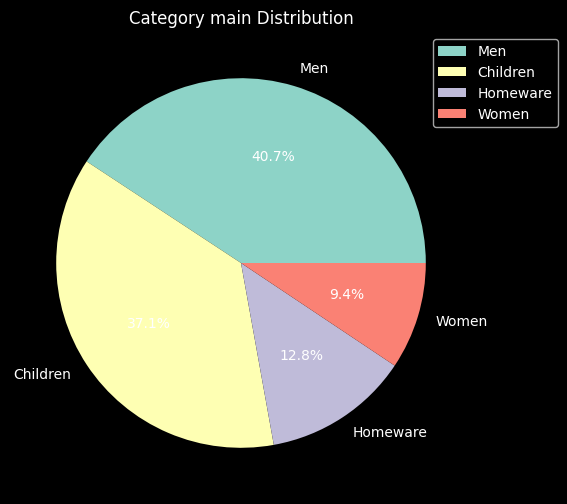

In [104]:
visualise_value_proportion(df, column="Category_main", chart_title="Category main Distribution")

Verify the value of Category sub

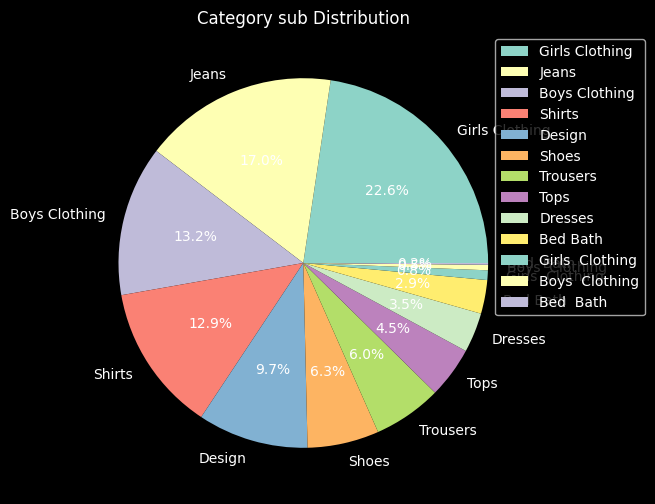

In [105]:
visualise_value_proportion(df, column="Category_sub", chart_title="Category sub Distribution")

There are some value duplication because of extra white spaces. Use regex to remove those.

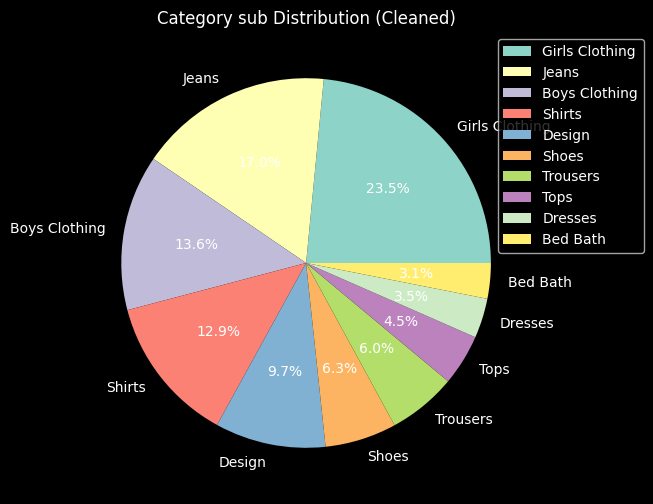

In [106]:
df['Category_sub'] = df['Category_sub'].str.replace(r'\s+', ' ', regex=True).str.strip()

visualise_value_proportion(df, column="Category_sub", chart_title="Category sub Distribution (Cleaned)")

## 1.5. Quantity Column
The quantity values look cleaned. No preprocess step needed

In [107]:
df["Quantity"].sample(10)

1338    1
657     1
91      1
1718    1
1291    1
1094    1
1666    2
669     1
276     1
1644    1
Name: Quantity, dtype: int64

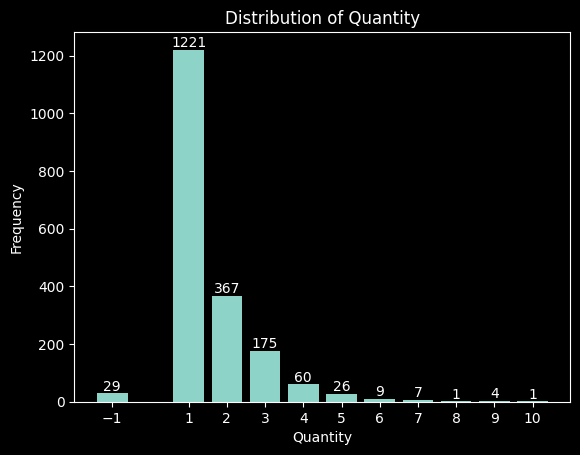

In [108]:
counts = df['Quantity'].value_counts().sort_index()

bars = plt.bar(counts.index, counts.values)

plt.xlabel("Quantity")
plt.xticks(counts.index)
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")

# add count labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=height,
        s=str(height),
        ha='center',
        va='bottom'
    )

plt.show()

## 1.6. Total Price / Total Profit Column

Two columns include currency notations, which may interfere with numerical analysis. Assume the values are in Euro and remove the currency symbols. Based on observation, two notations are present: `EUR` and `€`.

Use a regex pattern to remove these notations, then attempt to convert the values to a float. If the conversion fails, it may indicate the presence of other unexpected symbols or formats, leaving the value as a string (i.e., not convertible to float).

In [109]:
df[["Total Price", "Total Profit"]].sample(10)

,Total Price,Total Profit
1059,€ 35.00,€ 17.85
1663,€ 23.50,€ 9.40
732,154.80,60.20
347,€ 29.00,€ 11.60
648,16.50,8.41
1018,EUR 37.00,EUR 18.87
1164,€96.00,€48.96
1133,53.00,20.14
603,€ 46.00,€ 18.40
36,€ 35.00,€ 17.85


In [110]:
pattern = r'(€|EUR)'

df['Total Price'] = df['Total Price'].str.replace(pattern, '', regex=True).str.strip().astype(float)
df['Total Profit'] = df['Total Profit'].str.replace(pattern, '', regex=True).str.strip().astype(float)
df[['Total Price', 'Total Profit']].sample(10)

,Total Price,Total Profit
284,75.60,23.52
480,24.00,11.76
1069,16.50,8.41
629,29.70,8.25
1508,15.75,7.17
954,48.00,19.20
1298,33.00,13.20
1103,53.00,20.14
389,29.00,11.60
103,21.60,12.00


## 1.7. Payment Type Column
There are duplicated values because of redundant whitespaces. Use regex to remove those. `Pay Pal` and `CC` will be mapped manually to the correct value.

In [111]:
df["Payment Type"].sample(10)

424     Credit Card
1074    Credit Card
165     Credit Card
228         Pay Pal
1032    Credit Card
274      Debit Card
444      Debit Card
831          PayPal
305     Credit Card
490      Debit Card
Name: Payment Type, dtype: str

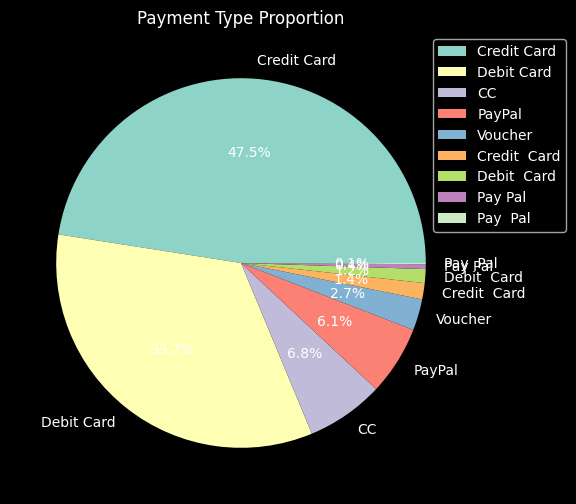

In [112]:
visualise_value_proportion(df, column="Payment Type", chart_title="Payment Type Proportion")

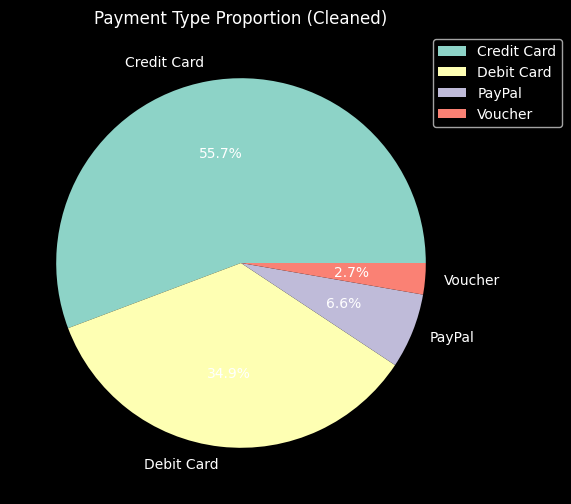

In [113]:
df['Payment Type'] = df['Payment Type'].str.replace(r'\s+', ' ', regex=True).str.strip()
df['Payment Type'] = df['Payment Type'].str.replace({"Pay Pal": "PayPal", "CC": "Credit Card"})

visualise_value_proportion(df, column="Payment Type", chart_title="Payment Type Proportion (Cleaned)")

## 1.8. Customer Detail Column
The column contains raw text describing the customer detail. Different set of field and values are separated by newline character on crawling. Using this character to convert those data to new columns

In [114]:
df["Customer Details"].head()

0    Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...
1    Customer ID: 10753\nLocation Laois\nGender: F\...
2    ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...
3    Age Range: 35-44\nGender: Male\nLocation: Lout...
4    ID: 12591\nCity: Dublin\nGender: Female\nAge G...
Name: Customer Details, dtype: str

After some sample iteration, most fields follow `{key}: {value}` except `ID` and `Location`. Extract those into columns with name is the key part. For those exceptions, the values are the part after whitespace of `ID` and `Location`.

Example:
- `Customer ID: 1` -> column: `Customer ID`, value: `1`
- `ID 1` -> column: `ID`, value: `1`

Besides those exceptions, if there are any other fields not following the pattern, error will be raised.

In [115]:
def parse_customer_info_strict(info_str):
    # Define exception patterns
    exception_patterns = {
        r'^ID\s+(.+)$': 'ID',
        r'^Location\s+(.+)$': 'Location'
    }

    data_dict = {}
    for line in info_str.split('\n'):
        line = line.strip()
        if not line:
            continue

        matched = False
        # Check exceptions case
        for pattern, col_name in exception_patterns.items():
            match = re.match(pattern, line)
            if match:
                data_dict[col_name] = match.group(1).strip()
                matched = True
                break

        if matched:
            continue

        # All other lines must be key: value
        if ':' in line:
            key, value = line.split(':', 1)
            data_dict[key.strip()] = value.strip()
        else:
            # Neither exception nor key:value → raise error
            raise ValueError(f"Invalid line format: '{line}'")


    return data_dict

customer_detail_df = (
    df['Customer Details']
    .apply(parse_customer_info_strict)
    .apply(pd.Series) # Since parse_customer_info_strict return a dict, we need to convert to a series
)

customer_detail_df.head(30)


,Cust ID,From,Gender,Age Range,Customer ID,Location,Age Group,ID,Age Category,City,Age
0,7097,Dublin,Female,25-34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,F,NaN,10753,Laois,35—44,NaN,NaN,NaN,NaN
2,NaN,NaN,Male,NaN,NaN,NaN,NaN,17356,55—64,Mayo,NaN
3,NaN,NaN,Male,35-44,9750,Louth,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Female,NaN,NaN,NaN,35-44,12591,NaN,Dublin,NaN
5,7822,NaN,Female,NaN,NaN,Kerry,45-54,NaN,NaN,NaN,NaN
6,NaN,NaN,Male,25-34,18791,NaN,NaN,NaN,NaN,Dublin,NaN
7,NaN,NaN,Female,18-24,12619,NaN,NaN,NaN,NaN,Kildare,NaN
8,17834,NaN,Male,NaN,NaN,Laois,NaN,NaN,35-44,NaN,NaN
9,1331,NaN,Female,25-34,NaN,Dublin,NaN,NaN,NaN,NaN,NaN


### 1.8.1. Customer ID Column

The Customer ID may be derived from one of three columns: `Cust ID`, `Customer ID`, or `ID`.

For each record, only one of these columns is expected to contain a value, while the other two should be `NaN`.

In [116]:
cols = ["Cust ID", "Customer ID", "ID"]

print("Number of data with duplicated customer ID value: ", (customer_detail_df[cols].notna().sum(axis=1) != 1).sum())

Number of data with duplicated customer ID value:  0


The non-NaN value among these columns should be treated as the Customer ID. Retain a single consolidated column and discard the others.

In [117]:
customer_detail_df["Customer ID"] = customer_detail_df[cols].bfill(axis=1).iloc[:, 0]
customer_detail_df = customer_detail_df.drop(["Cust ID", "ID"], axis=1)

customer_detail_df.sample(5)

,From,Gender,Age Range,Customer ID,Location,Age Group,Age Category,City,Age
1097,NaN,M,NaN,2359,NaN,NaN,NaN,Dublin,45—54
1707,NaN,F,NaN,7146,Cork,NaN,NaN,NaN,18-24
1834,Dublin,Male,NaN,15975,NaN,65+,NaN,NaN,NaN
1143,NaN,Male,NaN,6227,Cork,NaN,NaN,NaN,25—34
1422,NaN,Male,NaN,16250,Cork,55-64,NaN,NaN,NaN


In [118]:
print("Number of data with duplicated customer ID value: ", customer_detail_df["Customer ID"].isna().sum())

Number of data with duplicated customer ID value:  0


### 1.8.2. Location Column

The Location may be derived from one of three columns: `From`, `Location`, or `City`.

For each record, only one of these columns is expected to contain a value, while the other two should be `NaN`.

In [119]:
cols = ["From", "Location", "City"]
print("Number of data with duplicated location value: ", (customer_detail_df[cols].notna().sum(axis=1) != 1).sum())

Number of data with duplicated location value:  0


The non-NaN value among these columns should be treated as the Location. Retain a single consolidated column and discard the others.

In [120]:
customer_detail_df["Location"] = customer_detail_df[cols].bfill(axis=1).iloc[:, 0]
customer_detail_df = customer_detail_df.drop(["From", "City"], axis=1)

customer_detail_df.sample(5)

,Gender,Age Range,Customer ID,Location,Age Group,Age Category,Age
903,Male,NaN,17137,Kildare,NaN,NaN,35—44
1326,F,NaN,1587,Tipperary,NaN,25—34,NaN
253,F,NaN,15050,Dublin,NaN,NaN,18-24
680,Female,NaN,13434,Mayo,35—44,NaN,NaN
199,M,NaN,7559,Cork,35-44,NaN,NaN


### 1.8.3. Age Group Column

The Age Group may be derived from one of three columns: `Age Range`, `Age Group`, `Age Category` or `Age`.

For each record, only one of these columns is expected to contain a value, while the other two should be `NaN`.

In [121]:
cols = ["Age Range", "Age Group", "Age Category", "Age"]
print("Number of data with duplicated age group value: ", (customer_detail_df[cols].notna().sum(axis=1) != 1).sum())

Number of data with duplicated age group value:  0


The non-NaN value among these columns should be treated as the Age Group. Retain a single consolidated column and discard the others.


In [122]:
customer_detail_df["Age Group"] = customer_detail_df[cols].bfill(axis=1).iloc[:, 0]
customer_detail_df = customer_detail_df.drop(["Age Range", "Age Category", "Age"], axis=1)

customer_detail_df.sample(5)

,Gender,Customer ID,Location,Age Group
1742,Female,5969,Kildare,45-54
246,Female,4226,Tipperary,35–44
401,Female,13144,Laois,25–34
626,Female,6217,Roscommon,18–24
1831,Male,9925,Kildare,25-34


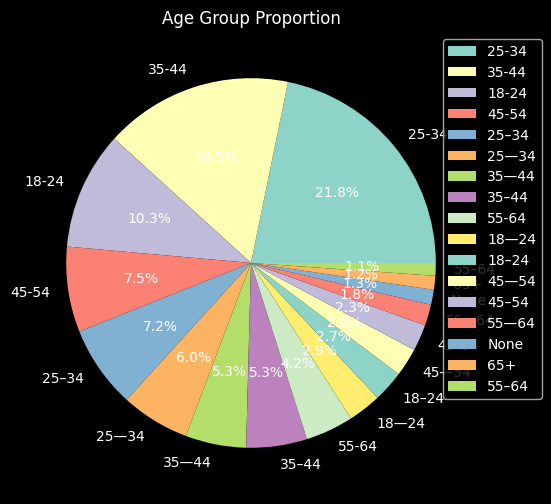

In [123]:
visualise_value_proportion(customer_detail_df, column="Age Group", chart_title="Age Group Proportion")

Duplicate values exist due to inconsistent dash formats. Use a regex pattern to normalize all dash variations into a single standard type.

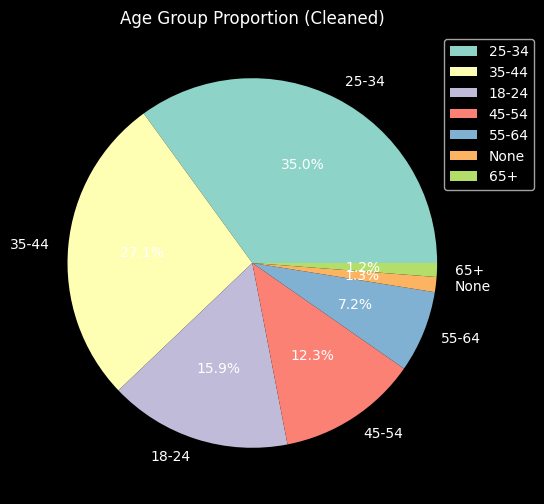

In [124]:
pattern = r'\s*[\u2013\u2014]+\s*'
customer_detail_df['Age Group'] = customer_detail_df['Age Group'].str.replace(pattern, '-', regex=True).str.strip()

visualise_value_proportion(customer_detail_df, column="Age Group", chart_title="Age Group Proportion (Cleaned)")

### 1.8.4. Gender Column

In [125]:
customer_detail_df["Gender"].sample(10)

1809               Female
1813    Prefer not to say
1340                 Male
196                     F
1222                 Male
1754               Female
1378               Female
149                Female
1792                 Male
389                Female
Name: Gender, dtype: str

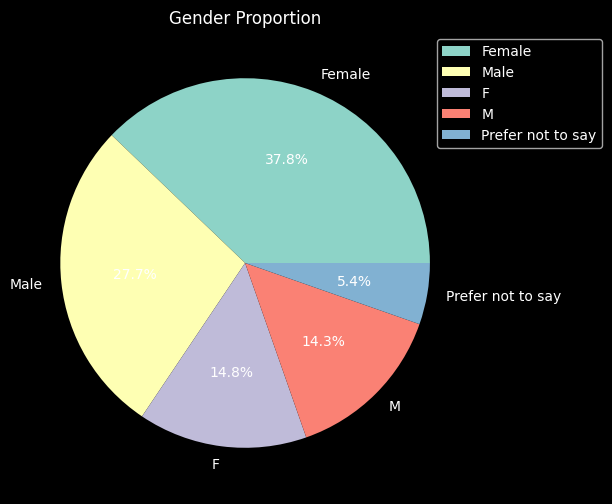

In [126]:
visualise_value_proportion(customer_detail_df, column="Gender", chart_title="Gender Proportion")

F is the shortcut of Female, and M is Male. Those shortcut will be converted to the full word. `Prefer not to say` is also removed.

In [127]:
mapping_rule = {
    "F": "Female",
    "M": "Male",
    "Prefer not to say": np.nan,
}

customer_detail_df["Gender"] = customer_detail_df['Gender'].replace(mapping_rule)

customer_detail_df["Gender"].sample(10)


691       Male
1720    Female
1698    Female
1010      Male
900     Female
394     Female
1876      Male
875     Female
991        NaN
68      Female
Name: Gender, dtype: str

### 1.8.5. Integrate preprocessed customer detail into main data

In [128]:
df = df.join(customer_detail_df, how="inner")

df.drop(["Customer Details"], axis=1, inplace=True)

df.sample(10)

,Product,Sale Date,Quantity,Total Price,Total Profit,Payment Type,Category_main,Category_sub,Gender,Customer ID,Location,Age Group
783,Lattice Runner,2025-05-23,1,86.0,34.40,Credit Card,Homeware,Design,Female,4072,Dublin,18-24
1364,Hawaiian Print Sun Safe Two Piece,2025-09-13,1,17.5,8.93,Debit Card,Children,Girls Clothing,Male,14087,Dublin,18-24
1163,Black Loose Fit Jeans,2025-08-06,1,29.0,11.60,Debit Card,Men,Jeans,Male,13631,Dublin,35-44
71,White Tie and Shirt Set,2025-07-03,3,105.0,39.90,Credit Card,Men,Shirts,Female,15828,Cork,35-44
73,Black Skinny Zip Trousers,2025-03-07,1,46.0,22.54,Credit Card,Men,Trousers,Male,4716,Clare,35-44
909,White Tie and Shirt Set,2025-06-14,2,70.0,26.60,Credit Card,Men,Shirts,Male,12459,Dublin,35-44
852,Black Jersey Denim Leggings,2025-05-06,1,57.0,27.93,PayPal,Men,Trousers,Female,1728,Cork,25-34
1198,Black Mary Jane Shoes,2025-08-13,1,39.6,15.40,Debit Card,Women,Shoes,Male,10197,Wexford,18-24
101,Lilac/Mint Long Sleeve Shirts,2025-10-02,2,52.0,26.52,Debit Card,Children,Girls Clothing,Male,8291,Kerry,45-54
1527,Hawaiian Print Sun Safe Two Piece,2025-10-19,1,17.5,8.93,Credit Card,Children,Girls Clothing,Male,13544,Waterford,25-34


# 2. Analysis

## 2.1. Overall

### 2.1.2. Revenue

In [129]:
print(f"Total Profit: EUR {df['Total Profit'].sum()}")
print(f"Total Revenue: EUR {df['Total Price'].sum()}")
print(f"Profit Margin: {round(df['Total Profit'].sum()/df['Total Price'].sum(), 4) * 100} %")

Total Profit: EUR 42782.18
Total Revenue: EUR 99461.9
Profit Margin: 43.01 %


### 2.1.2. Profit Margin by Categories

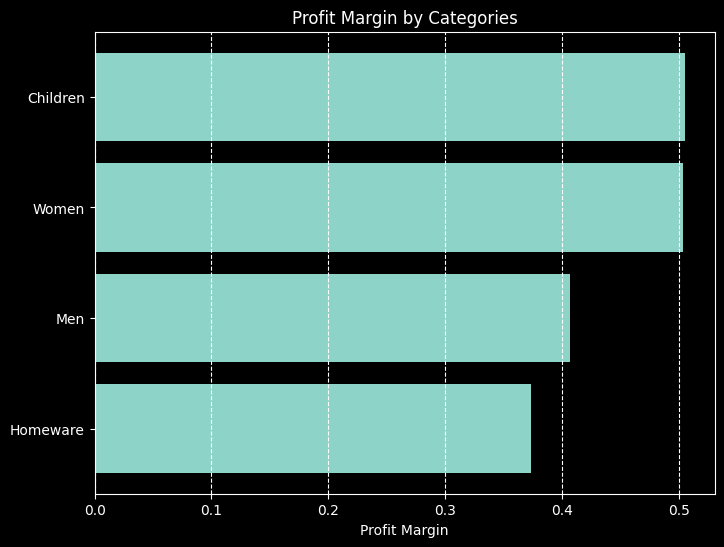

In [141]:
# Aggregate
product_stats = df.groupby('Category_main').agg({
    'Total Profit': 'sum',
    'Total Price': 'sum',
}).reset_index()

# Profit Margin
product_stats['Profit Margin'] = product_stats['Total Profit'] / product_stats['Total Price']

# Sort Profit Margin from highest to lowest
all_categories = product_stats.sort_values(by='Profit Margin', ascending=False)

# Draw the bar chart
plt.figure(figsize=(8,6))

# Invert y-axis so the highest profit margin is on top
plt.gca().invert_yaxis()

bars = plt.barh(all_categories['Category_main'], all_categories['Profit Margin'])
plt.title('Profit Margin by Categories')
plt.xlabel('Profit Margin')
plt.grid(True, axis='x', linestyle='--')


plt.show()

### 2.1.3. Top 10 highest profit product

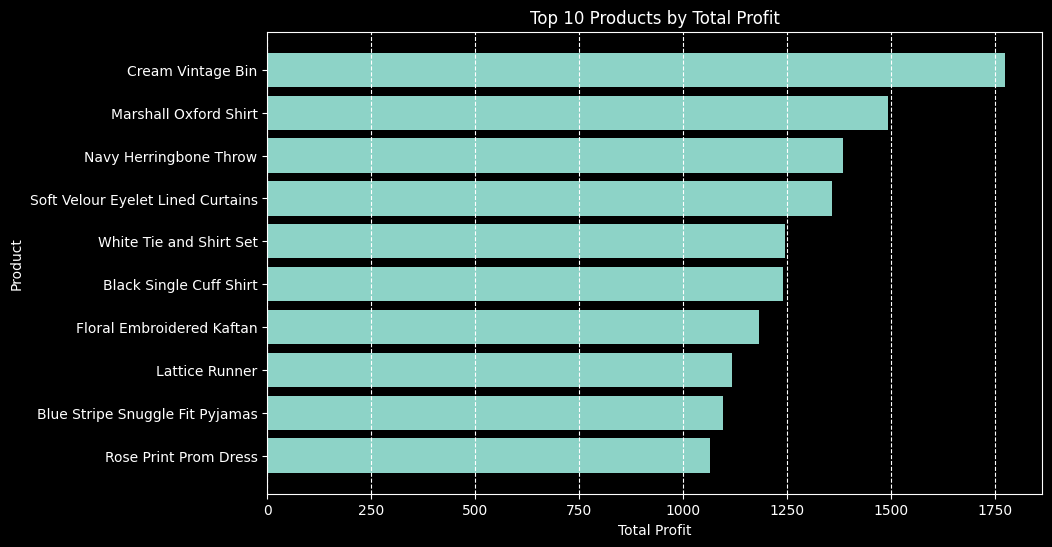

In [140]:
# Aggregate total profit and total quantity by Product
summary = df.groupby('Product').agg({
    'Total Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

# Get top 10 products by Total Profit
top10 = summary.sort_values(by='Total Profit', ascending=False).head(10)

# Plot horizontal bars for Total Profit
plt.figure(figsize=(10, 6))
bars = plt.barh(top10['Product'], top10['Total Profit'])

# Invert y-axis so the highest profit is on top
plt.gca().invert_yaxis()

plt.xlabel('Total Profit')
plt.ylabel('Product')
plt.title('Top 10 Products by Total Profit')
plt.grid(True, axis='x', linestyle='--')
plt.show()

## 2.2. Revenue Trend

### 2.2.1. Weekly Revenue

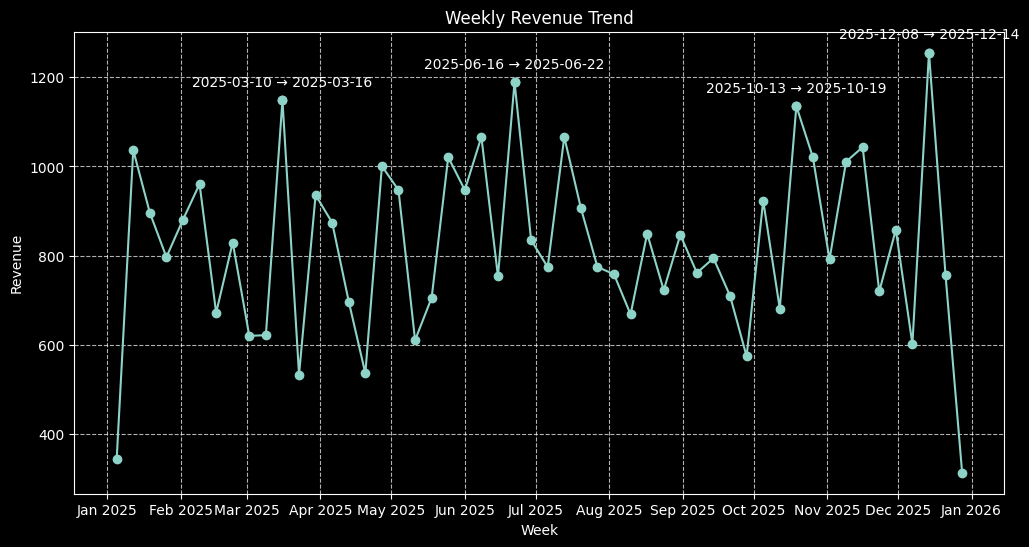

In [132]:
# Create a working copy so the original dataframe is not modified
df_weekly = df.copy()

# Set index for resampling
df_weekly = df_weekly.set_index('Sale Date')

# Aggregate revenue by week
weekly_revenue = df_weekly['Total Profit'].resample('W').sum()

# Identify top 4 peak weeks
top4 = weekly_revenue.nlargest(4)

# Plot weekly revenue trend
plt.figure(figsize=(12,6))
plt.plot(weekly_revenue.index, weekly_revenue.values, marker='o')

# Highlight peaks
plt.scatter(top4.index, top4.values, zorder=3, label="Top 4 Peaks")

# Annotate peaks with week duration
for week_end, revenue in top4.items():
    week_start = week_end - pd.Timedelta(days=6)
    label = f"{week_start.date()} → {week_end.date()}"

    plt.annotate(
        label,
        (week_end, revenue),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # every month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Jan 2025, etc.

ax.grid(True, linestyle='--', alpha=0.7)

plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.show()

There are four weeks with notably high revenue:

- 03-10 → 03-16: Week before St. Patrick’s holiday
- 06-16 → 06-22: Not associated with a specific event, but may coincide with the start of summer
- 10-13 → 10-19: Week before Halloween
- 12-08 → 12-14: Week before Christmas

Outside of these peaks, revenue remains relatively stable throughout the year, though there is noticeable week-to-week fluctuation. Increases in revenue often occur around the beginning or end of the month, which may align with typical payday cycles, when spending tends to rise.

### 2.2.2. Category Revenue Share during Peak Duration

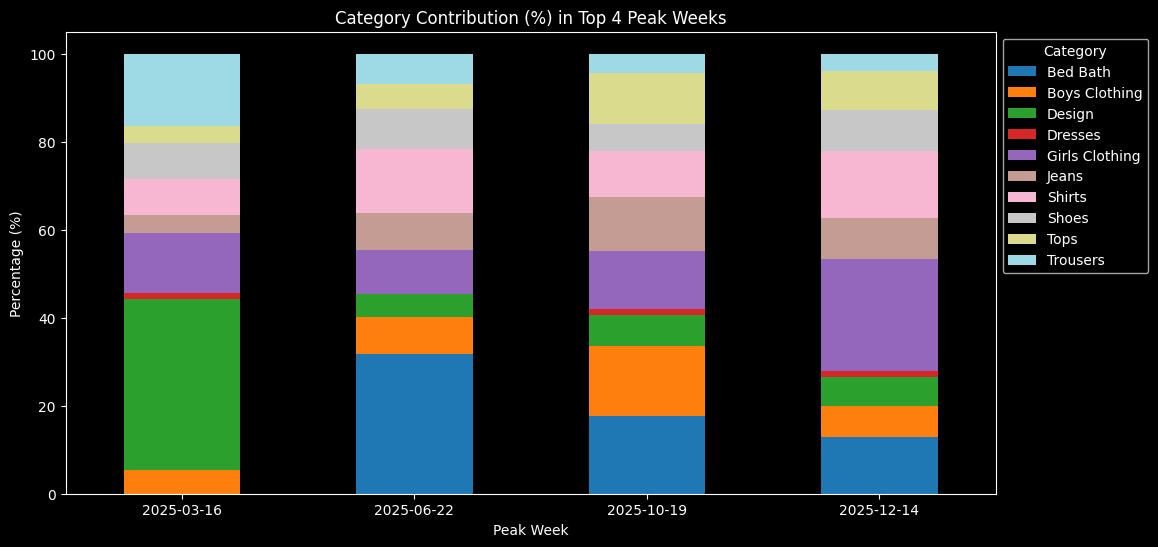

In [133]:
# Make Week_End aligned with weekly resample
df_weekly['Week_End'] = df_weekly.index.to_period('W').to_timestamp('W')

# Show only the peak weeks
df_peaks = df_weekly[df_weekly['Week_End'].isin(top4.index)]

# Aggregate total profit by category within each peak week
category_mix = (
    df_peaks
    .groupby(['Week_End', 'Category_sub'])['Total Profit']
    .sum()
    .reset_index()
)

# Compute percentage contribution per week
category_mix['Percentage'] = (
    category_mix.groupby('Week_End')['Total Profit']
    .transform(lambda x: x / x.sum() * 100)
)

# Pivot for stacked bar visualization
pivot_df = category_mix.pivot(
    index='Week_End',
    columns='Category_sub',
    values='Percentage'
).fillna(0)

# Plot stacked bar chart
ax = pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='tab20'
)

plt.title("Category Contribution (%) in Top 4 Peak Weeks")
plt.xlabel("Peak Week")
plt.ylabel("Percentage (%)")

# Format x-axis labels
plt.xticks(
    ticks=range(len(pivot_df.index)),
    labels=[d.strftime('%Y-%m-%d') for d in pivot_df.index],
    rotation=0,
)

plt.legend(title="Category", bbox_to_anchor=(1, 1))
plt.show()

The peak season before Halloween (2025-10-19) shows that all categories contributed nearly equally to revenue.

For the other peak periods, specific categories dominated:

- 2025-03-16: **Design**
- 2025-06-22: **Bed & Bath**
- 2025-12-14: **Girl Clothing**

Except for the first peak, the shop's revenue is largely driven by different clothing categories.

## 2.3. Customer Return Rate

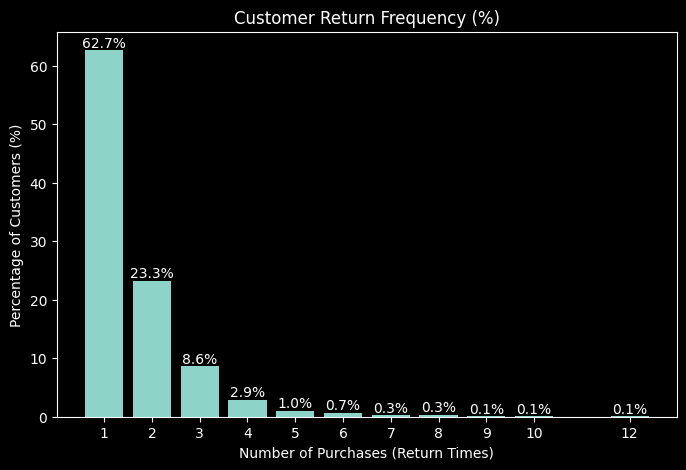

In [134]:
# Number of purchases per customer
customer_purchases = df.groupby('Customer ID').size()

# Distribution of purchase counts
return_distribution = customer_purchases.value_counts().sort_index()

# Convert to percentage
percentage_distribution = (return_distribution / return_distribution.sum()) * 100

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(percentage_distribution.index, percentage_distribution.values)

plt.xlabel('Number of Purchases (Return Times)')
plt.ylabel('Percentage of Customers (%)')
plt.title('Customer Return Frequency (%)')

plt.xticks(percentage_distribution.index)

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

The visualization clearly shows that most customers purchase only once or twice and do not return for additional purchases.

## 2.4. Sale Performance on Location

### 2.4.1. Revenue by location

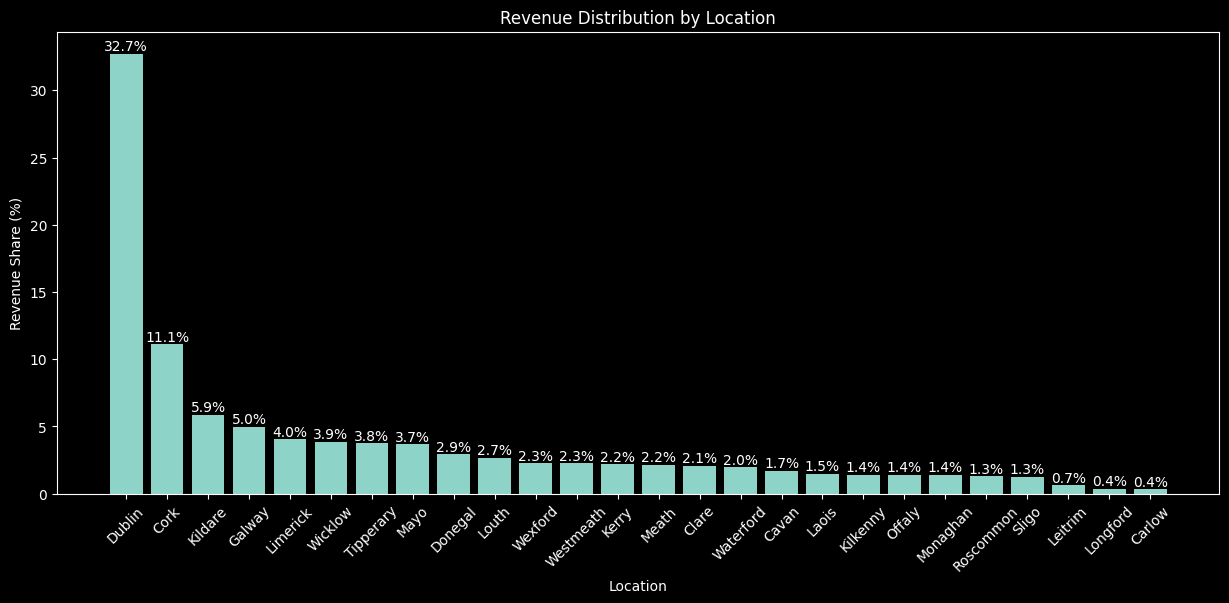

In [135]:
# Total revenue by location
revenue_location = df.groupby('Location')['Total Price'].sum()

# Convert to percentage of total revenue
revenue_percentage = (revenue_location / revenue_location.sum()) * 100

revenue_percentage = revenue_percentage.sort_values(ascending=False)

# Plot
plt.figure(figsize=(15,6))
bars = plt.bar(revenue_percentage.index, revenue_percentage.values)

plt.xlabel('Location')
plt.ylabel('Revenue Share (%)')
plt.title('Revenue Distribution by Location')
plt.xticks(rotation=45)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

The visualization clearly indicates that revenue is primarily generated from Dublin, followed by Cork, while other branches contribute roughly similar, smaller amounts.


### 2.4.2. Locations Contributing to 50% of Revenue

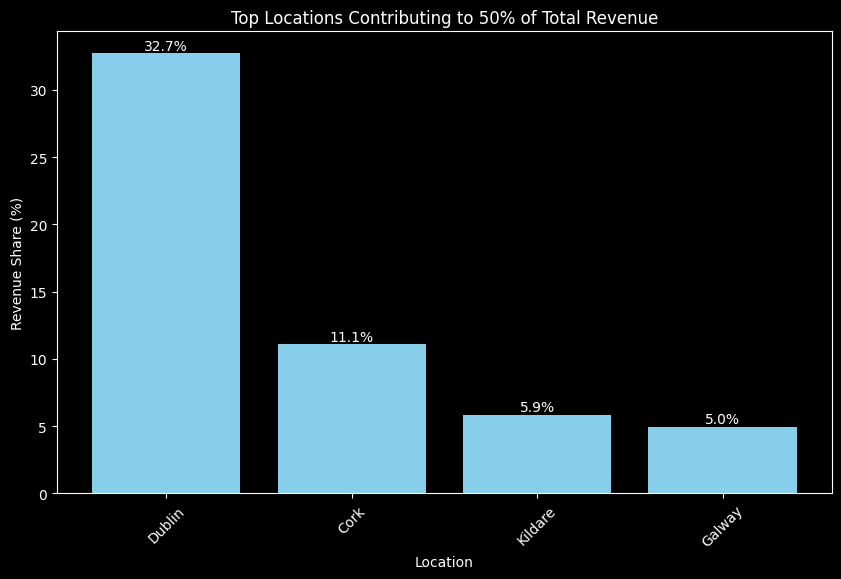

In [136]:
# Compute revenue per location
revenue_location = df.groupby('Location')['Total Price'].sum().sort_values(ascending=False)

# Convert to percentage of total revenue
revenue_percentage = (revenue_location / revenue_location.sum()) * 100

# Cumulative percentage
cumulative_percentage = revenue_percentage.cumsum()

# Select top locations contributing to ~50% of revenue
top_locations = revenue_percentage[cumulative_percentage <= 50]

# Include the location that crosses 50%
top_locations = revenue_percentage.iloc[:len(top_locations)+1]

# Visualize top locations
plt.figure(figsize=(10,6))
bars = plt.bar(top_locations.index, top_locations.values, color='skyblue')
plt.xlabel('Location')
plt.ylabel('Revenue Share (%)')
plt.title('Top Locations Contributing to 50% of Total Revenue')
plt.xticks(rotation=45)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}%', ha='center', va='bottom')

plt.show()

# Filter the dataframe for top locations for further analysis
top_df = df[df['Location'].isin(top_locations.index)]

Dublin, Cork, Kildare, and Galway together contribute more than 50% of the total revenue.

### 2.4.3. Gender Distribution by Location

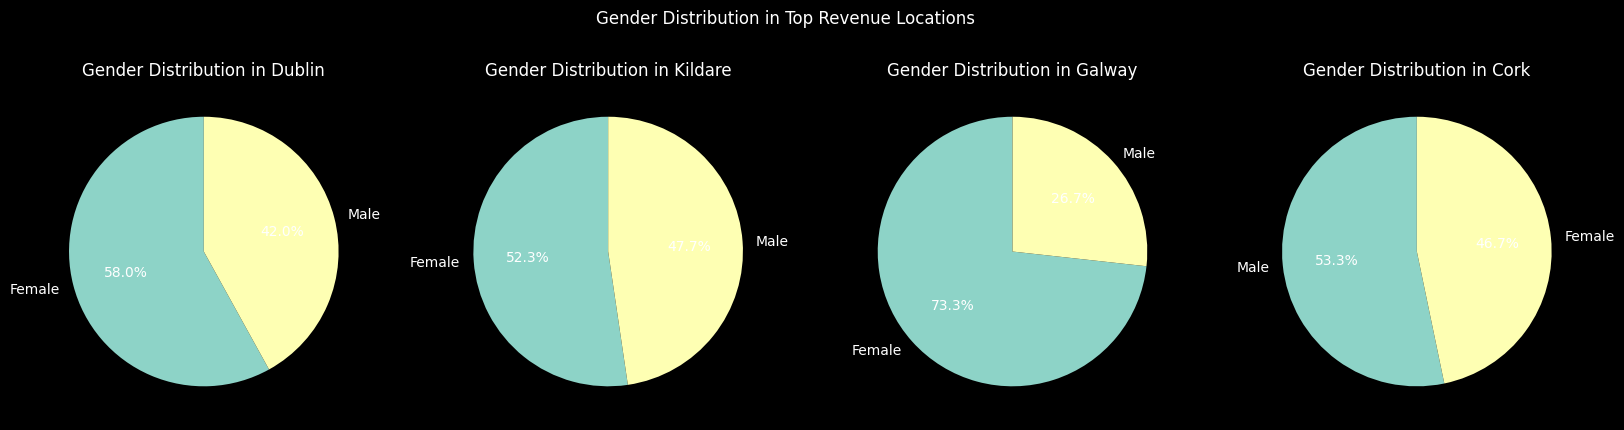

In [137]:
# Get the list of top locations
locations = top_df['Location'].unique()

# Set up subplots: one pie chart per city
n = len(locations)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

# If only one location, axes is not a list, so we need explicit check here
if n == 1:
    axes = [axes]

for ax, loc in zip(axes, locations):
    city_data = top_df[top_df['Location'] == loc]
    gender_dist = city_data['Gender'].value_counts()

    ax.pie(gender_dist, labels=gender_dist.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'Gender Distribution in {loc}')

plt.suptitle('Gender Distribution in Top Revenue Locations')
plt.show()

Except for Galway, other locations show a roughly equal distribution of male and female customers. Galway, however, has a higher proportion of female customers.

### 2.4.4. Age Distribution in Top Revenue Locations

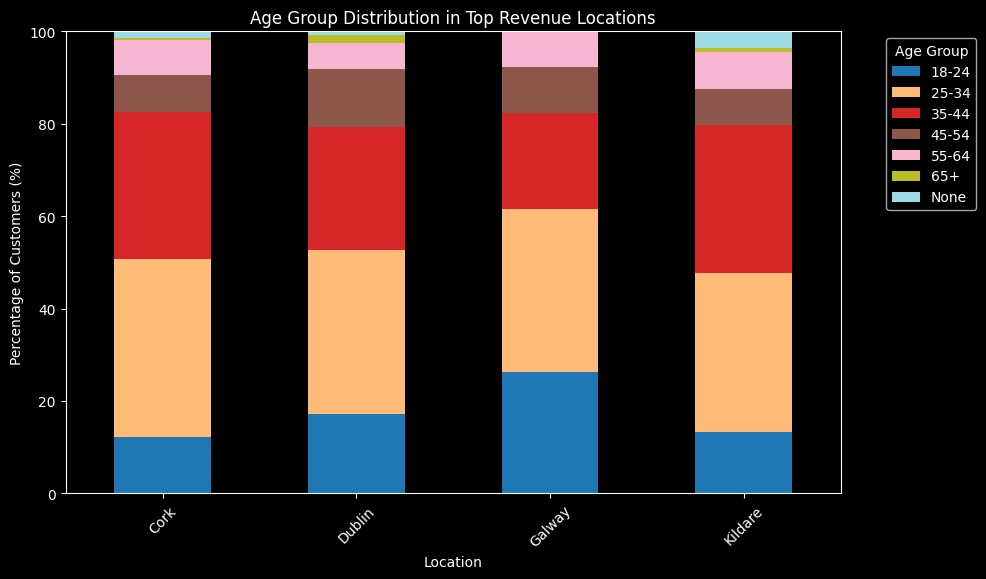

In [138]:
# Count of customers per Age Group per Location
age_location = top_df.groupby(['Location', 'Age Group']).size().unstack(fill_value=0)

# Convert counts to percentages per city
age_location_pct = age_location.div(age_location.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
age_location_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')

plt.ylabel('Percentage of Customers (%)')
plt.xlabel('Location')
plt.title('Age Group Distribution in Top Revenue Locations')
plt.xticks(rotation=45)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

The majority of customers in all top locations fall within the 25–34 and 35–44 age groups, with the 25–34 group having a slightly higher proportion than the 35–44 group.

# 3. Conclusion

## Challenges
1. Customer details are stored in raw text format, which introduces challenges in extraction and structuring.
2. The `Quantity` column contains `-1` values, creating ambiguity as it is unclear whether this represents a data entry error or a special indicator.

## Key Insights
1. Revenue was stable throughout the year, with noticeable week-to-week fluctuations. Peak periods - typically before major events - show higher revenue.
2. The majority of revenue is driven by clothing categories. During the first peak season, the **Design** category showed a significant spike, suggesting strong customer interest in particular products in the retail shop.
3. Customer distribution is relatively balanced across genders, with a slightly higher in the woman percentage.
4. The dominant customer segments fall within the 25–34 and 35–44 age groups - typically working individuals with income. This is further supported by revenue spikes around payday periods and Dublin - a major employment hub - generates the highest revenue.

## Further Work
1. *Forecasting*: Apply historical sales data to predict future revenue and category-level demand, supporting inventory planning.
2. *Regional Performance*: Analyze which locations generate the most revenue versus profit, and identify underperforming categories specific to certain regions.
3. *Customer Retention Analysis*: Investigate the root causes of low customer return rates by examining factors such as region, category, pricing, and customer behavior.